Alexander Faust
May 10, 2025
Stochastic Calculus Problem Set
 
This script relied on the use of Claude 3.7 Sonnet for generation purposes. I have modified sections of its output depending on the quality of output.

Number of significant lags (>0.2): 10

Eigenvalues of Toeplitz matrix C:
[7.89351636e-01 1.05889377e+00 1.43505999e+00 2.12532684e+00
 3.74209828e+00 8.90625019e+00 2.04756949e+01 7.06127769e+01
 2.49910769e+02 8.16012822e+02 2.67493096e+03]
All eigenvalues positive: True

L from LDL decomposition:
[[1.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.9607 1.     0.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.8675 1.6532 1.     0.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.7491 1.9198 1.7979 1.     0.     0.     0.     0.     0.     0.
  0.    ]
 [0.6277 1.8966 2.2038 1.7909 1.     0.     0.     0.     0.     0.
  0.    ]
 [0.5176 1.6939 2.2827 2.1843 1.7897 1.     0.     0.     0.     0.
  0.    ]
 [0.4252 1.4171 2.1211 2.2546 2.1821 1.7896 1.     0.     0.     0.
  0.    ]
 [0.3526 1.1223 1.8611 2.0813 2.2504 2.1805 1.7895 1.     0.     0.
  0.    ]
 [0.2976 0.8663 1.5338 1.8198 2.0766 2.2485 2.1805 1.7904 1.     0.
  0.    

TypeError: object of type 'numpy.float64' has no len()

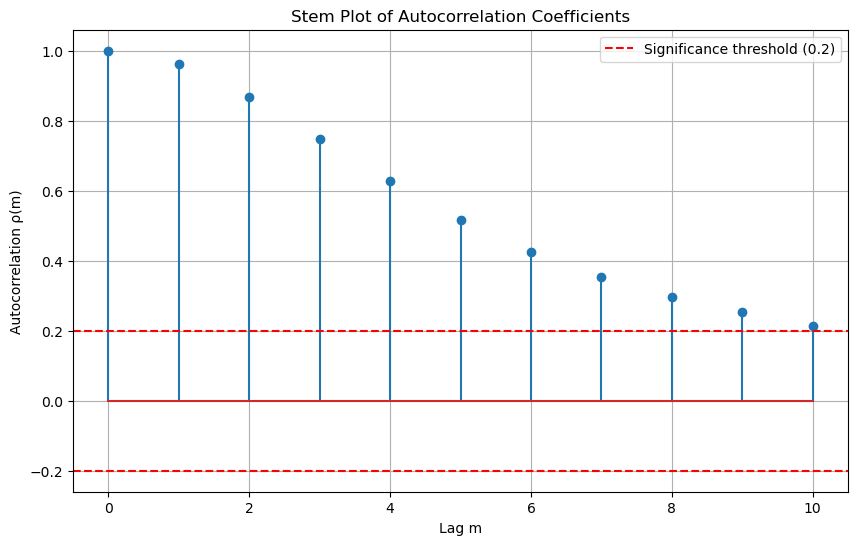

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, linalg
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.tsa.stattools import acf, levinson_durbin

# Alternative to linalg.ldl if it's buggy
def manual_ldl(A):
    n = A.shape[0]
    L = np.eye(n)
    D = np.zeros((n, n))
    
    for i in range(n):
        D[i, i] = A[i, i] - np.sum(L[i, :i]**2 * np.diag(D)[:i])
        
        for j in range(i+1, n):
            L[j, i] = (A[j, i] - np.sum(L[j, :i] * L[i, :i] * np.diag(D)[:i])) / D[i, i]
    
    return L, D, None  # Return None for perm to match API


np.random.seed(42)
'''
    AR and ARMA modeling

    (a) Generate data using ARMA(2,2) model
    Convert the ARMA model from operator notation to coefficient arrays

    ARMA(2,2) model:
    r_t = [(1 + 0.2z^-1)(1 + 0.5z^-1)]/[(1 - 0.8z^-1)(1 - 0.7z^-1)] * v_t

    Calculate MA coefficients by multiplying (1 + 0.2z^-1)(1 + 0.5z^-1) = 1 + 0.7z^-1 + 0.1z^-2
'''
ma = np.polymul([1, 0.2], [1, 0.5])

# Calculate AR coefficients by multiplying (1 - 0.8z^-1)(1 - 0.7z^-1) = 1 - 1.5z^-1 + 0.56z^-2
ar = np.polymul([1, -0.8], [1, -0.7])

# Generate N = 250 samples
N = 250
v_t = np.random.normal(0, 1, N+100)  # Add extra samples for burn-in
r_t = arma_generate_sample(ar, ma, nsample=N+100, burnin=100)  # Discard first 100 for burn-in

# Part (a): Estimate covariances and create stem plot
M = 10  # Maximum order specified
gamma = acf(r_t, nlags=M, fft=False) * len(r_t)  # Multiply by len to get covariance instead of correlation
rho = gamma / gamma[0]  # Normalize to get correlation coefficients

plt.figure(figsize=(10, 6))
plt.stem(range(M+1), rho)
plt.axhline(y=0.2, color='r', linestyle='--', label='Significance threshold (0.2)')
plt.axhline(y=-0.2, color='r', linestyle='--')
plt.xlabel('Lag m')
plt.ylabel('Autocorrelation ρ(m)')
plt.title('Stem Plot of Autocorrelation Coefficients')
plt.grid(True)
plt.legend()

# Count significant lags
significant_lags = sum(abs(rho[1:]) > 0.2)
print(f"Number of significant lags (>0.2): {significant_lags}")

# Part (b): Set up Toeplitz matrix and compute eigenvalues
C = linalg.toeplitz(gamma[:M+1])
eigenvalues = linalg.eigvalsh(C)
print("\nEigenvalues of Toeplitz matrix C:")
print(eigenvalues)
print(f"All eigenvalues positive: {all(eigenvalues > 0)}")

# Part (c): Find LDL decomposition of covariance matrix C
try:
    L, D, perm = linalg.ldl(C)
except (AttributeError, ImportError):
    L, D, perm = manual_ldl(C)

print("\nL from LDL decomposition:")
print(np.round(L, 4))
print("\nD from LDL decomposition:")
print(np.round(D, 4))

# Part (d): Use Levinson-Durbin recursion
ld_results = []
reflection_coeffs = []
prediction_errors = []

for i in range(1, M+1):
    try:
        # Try without the allow_singular parameter
        result = levinson_durbin(gamma[:i+1])
        ld_results.append(result)
        
        # Handle different return formats
        if isinstance(result, tuple) and len(result) >= 3:
            # Extract reflection coefficients
            if isinstance(result[2], np.ndarray):
                reflection_coeffs.append(result[2][0] if len(result[2]) > 0 else 0)
            else:
                reflection_coeffs.append(result[2])
            
            # Extract prediction errors
            prediction_errors.append(result[1])
        else:
            # If result is not in expected format
            print(f"Warning: Unexpected format for order {i}")
    except Exception as e:
        print(f"Error in Levinson-Durbin for order {i}: {e}")
        # Add placeholder values to maintain array dimensions
        ld_results.append((np.zeros(i), 0, np.zeros(1)))
        reflection_coeffs.append(0)
        prediction_errors.append(0)

# Construct FPEF matrix 
F = np.eye(M+1)
for i in range(1, M+1):
    if i-1 < len(ld_results):
        ar_coeffs = ld_results[i-1][0]
        for j in range(1, i+1):
            if j-1 < len(ar_coeffs):
                F[i, i-j] = ar_coeffs[j-1]

print("\nLevinson-Durbin reflection coefficients:")
print(np.round(reflection_coeffs, 4))
print("\nPrediction error powers P_m:")
print(np.round(prediction_errors, 4))

# Part (e): Compute FCF^T and compare
FCF_T = F @ C @ F.T
print("\nDiagonal elements of FCF^T:")
print(np.round(np.diag(FCF_T), 4))
print("\nPrediction error powers P_m for comparison:")
print(np.round(prediction_errors, 4))

# Compare F with L^-1
L_inv = linalg.inv(L)
print("\nComparison of F and L^-1 (should be similar):")
print("F:")
print(np.round(F, 4))
print("L^-1:")
print(np.round(L_inv, 4))

# Part (f): Compute AR coefficients using least squares
# Prepare data for LS fit
X = np.zeros((N-M, M))
for i in range(M):
    X[:, i] = r_t[M-i-1:N-i-1]
y = r_t[M:N]

# LS fit
ar_ls = np.linalg.lstsq(X, y, rcond=None)[0]
print("\nAR coefficients using LS fit:")
print(np.round(ar_ls, 4))

print("\nAR coefficients from Levinson-Durbin (order M):")
print(np.round(ld_results[M-1][0], 4))

# Part (g): Analysis of reflection coefficients
print("\nReflection coefficients analysis:")
for i, rc in enumerate(reflection_coeffs):
    print(f"Order {i+1}: {rc:.4f}", end=" ")
    if abs(rc) > 0.9:
        print("- Close to 1: Suggests near non-stationarity or high persistence")
    elif abs(rc) < 0.1:
        print("- Close to 0: Suggests this order adds little predictive value")
    else:
        print("")

# Part (h): Model validation for different AR orders
ar_orders = [2, 5, 10]

plt.figure(figsize=(15, 10))
for i, order in enumerate(ar_orders):
    # Use AR coefficients from Levinson-Durbin
    ar_coef = ld_results[order-1][0]
    
    # Create AR model and get residuals
    # More robust residual calculation
    residuals = np.zeros_like(r_t)
    for t in range(order, len(r_t)):
        ar_terms = np.array([r_t[t-j-1] for j in range(order)])
        prediction = np.dot(ar_coef, ar_terms) if len(ar_coef) == order else 0
        residuals[t] = r_t[t] - prediction
    
    # Compute autocorrelation of residuals
    residual_acf = acf(residuals[order:], nlags=M, fft=False)
    
    # Plot
    plt.subplot(len(ar_orders), 1, i+1)
    plt.stem(range(M+1), residual_acf)
    plt.axhline(y=0.2, color='r', linestyle='--')
    plt.axhline(y=-0.2, color='r', linestyle='--')
    plt.title(f'Residual Autocorrelation for AR({order}) Model')
    plt.xlabel('Lag m')
    plt.ylabel('ρ(m)')
    plt.grid(True)
    
    # Check if all |ρ(m)| < 0.2 for m ≠ 0
    is_white = all(abs(residual_acf[1:]) < 0.2)
    print(f"\nAR({order}) model - residuals are white noise: {is_white}")

# Find optimal AR order by trial and error
if all(abs(residual_acf[1:]) < 0.2):  # If AR(10) is already sufficient
    min_order = 10
    for order in range(2, 10):
        ar_coef = ld_results[order-1][0]
        residuals = np.zeros_like(r_t)
        for t in range(order, len(r_t)):
            prediction = np.sum([ar_coef[j] * r_t[t-j-1] for j in range(order)])
            residuals[t] = r_t[t] - prediction
        residual_acf = acf(residuals[order:], nlags=M, fft=False)
        if all(abs(residual_acf[1:]) < 0.2):
            min_order = order
            break
    
    print(f"\nOptimal AR order (smallest that passes whiteness test): {min_order}")

plt.tight_layout()
plt.show()